# OSM preprocessing pipeline

**Objective**
Prepare the bundled OSM building-footprint case-study dataset up to the cleaned, artifact-filtered, hole-filtered, and angle-regularized working-set representation, then persist the final decomposition subset for the downstream notebook.

**Source credit**
The bundled GeoPackage is a reduced anonymized derivative of OpenStreetMap contributors data, redistributed here under ODbL 1.0. `ConvexDecomp` does not claim authorship of the underlying footprint source data.

**Workflow overview**
1. Load the bundled metric footprint dataset from `data/osm/osm_building_footprints_openstreetmap_odbl.gpkg`.
2. Normalize single-part `MultiPolygon` features back to `Polygon` while preserving true multipart cases for later filtering.
3. Remove clearly unsuitable shapes such as multipart footprints, wall-like strips, and over-holed plans.
4. Clean the remaining geometry through conservative normalization with an integrated final edge-regularization pass.
5. Inspect raw-input and final-working-set vertex-count and edge-direction distributions so the overall complexity reduction is visible at dataset scale.
6. Select the final decomposition working set by retaining still non-convex footprints with 6 to 32 exterior vertices, matching the paper.
7. Inspect representative retained examples and save the preprocessing output.

**Main artifacts written by this notebook**
- `data/osm/subset_buildings_gdf.pkl`


### Configure notebook environment
Load the paths and helpers used for preprocessing the bundled local-metric OSM building-footprint dataset.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython import get_ipython
from matplotlib import colormaps as cmaps
from matplotlib.lines import Line2D
from shapely.geometry import MultiPolygon, Polygon

ip = get_ipython()
# OSM benefits from widget plots when ipympl is available.
if ip is not None:
    try:
        ip.run_line_magic('matplotlib', 'widget')
    except Exception:
        ip.run_line_magic('matplotlib', 'inline')

from convexdecomp.notebook_utils import find_project_root

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
OSM_DATA_DIR = PROJECT_ROOT / 'data' / 'osm'
OSM_INPUT_GPKG = OSM_DATA_DIR / 'osm_building_footprints_openstreetmap_odbl.gpkg'
OSM_INPUT_LAYER = 'footprints'
SUBSET_BUILDINGS_PATH = OSM_DATA_DIR / 'subset_buildings_gdf.pkl'

SRC_DIR = PROJECT_ROOT / 'src'

for extra_path in (PROJECT_ROOT, SRC_DIR):
    if str(extra_path) not in sys.path:
        sys.path.insert(0, str(extra_path))

from convexdecomp.plotting.geometry_grid import GHSL_gridplot
from convexdecomp.plotting.osm_working_set import plot_working_set_prepost_comparison
from convexdecomp.plotting.polygons import fill_polygon_geometry, set_geometry_frame
from convexdecomp.osm.diagnostics import count_exterior_direction_groups, normalize_input_geometry, plot_alignment_family_showcase
from convexdecomp.osm.normalize import (
    FootprintNormalizationConfig,
    LinearArtifactFilterConfig,
    annotate_linear_artifact_flags,
    count_exterior_vertices,
    count_polygon_holes,
    normalize_buildings_gdf,
)
from convexdecomp.core.convexity import is_convex_polygon
from convexdecomp.osm.axis_alignment import (
    EdgeAlignmentConfig,
    alignment_axis_records_for_polygon,
)

plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['axes.titlesize'] = 10

EDGE_ALIGNMENT_CFG = EdgeAlignmentConfig(
    use_angle_families=True,
    family_angle_tol_deg=3.0,
    line_angle_tol_deg=2.0,
    line_offset_tol_m=0.2,
    collinear_tol_deg=1.0,
    min_seg_len_m=0.05,
    max_vertex_snap_shift_m=0.4,
    align_min_area_ratio=0.97,
    align_max_area_ratio=1.03,
    align_max_edge_stretch=2.0,
    align_max_hausdorff_m=0.5,
)


### Load the bundled building dataset
Read the bundled OSM footprint GeoPackage shipped with this repository. The file contains only anonymized `sample_id` values and footprint geometry. It is derived from OpenStreetMap contributors data and distributed under ODbL 1.0.


In [2]:
if not OSM_INPUT_GPKG.exists():
    raise FileNotFoundError(f'Missing bundled dataset {OSM_INPUT_GPKG}.')

buildings_gdf = gpd.read_file(OSM_INPUT_GPKG, layer=OSM_INPUT_LAYER)
buildings_gdf['geometry'] = buildings_gdf.geometry.apply(normalize_input_geometry)

print('buildings_gdf shape:', buildings_gdf.shape)
print('columns:', buildings_gdf.columns.tolist())
print('input layer:', OSM_INPUT_LAYER)
print('input CRS:', buildings_gdf.crs)
buildings_gdf.head()


buildings_gdf shape: (7140, 2)
columns: ['sample_id', 'geometry']
input layer: footprints
input CRS: EPSG:32633


,sample_id,geometry
0,osm_0001,"POLYGON ((-5.05 2.34, -0.79 5.47, 5.01 -2.65, ..."
1,osm_0002,"POLYGON ((2.31 -0.98, -0.4 -2.33, -2.38 0.7, 0..."
2,osm_0003,"POLYGON ((1.39 -5.92, -5.91 1.33, -1.52 5.8, 5..."
3,osm_0004,"POLYGON ((-0.38 9.27, 6.65 -3, 8.47 -5.51, 0.9..."
4,osm_0005,"POLYGON ((-0.75 6.08, 5.25 -3.04, 0.75 -6.08, ..."


### Plot the original OSM input distributions
Show two dataset-level summaries before any filtering or geometric cleaning. The first histogram counts exterior vertices per originally loaded footprint. The second counts distinct exterior edge directions per original single-polygon footprint, computed directly from the raw OSM geometry after folding opposite directions into the same orientation range `0-180°`. The direction count is evaluated with `angle_tol_deg=0.0`, so no angular grouping is applied and the plot intentionally exposes how noisy and over-detailed the raw input directions can be. Multipart inputs are excluded only from the direction histogram because this per-ring direction count is defined for a single exterior boundary. Both histograms use logarithmic count scales so the common simple cases and the rarer high-complexity cases stay visible together.


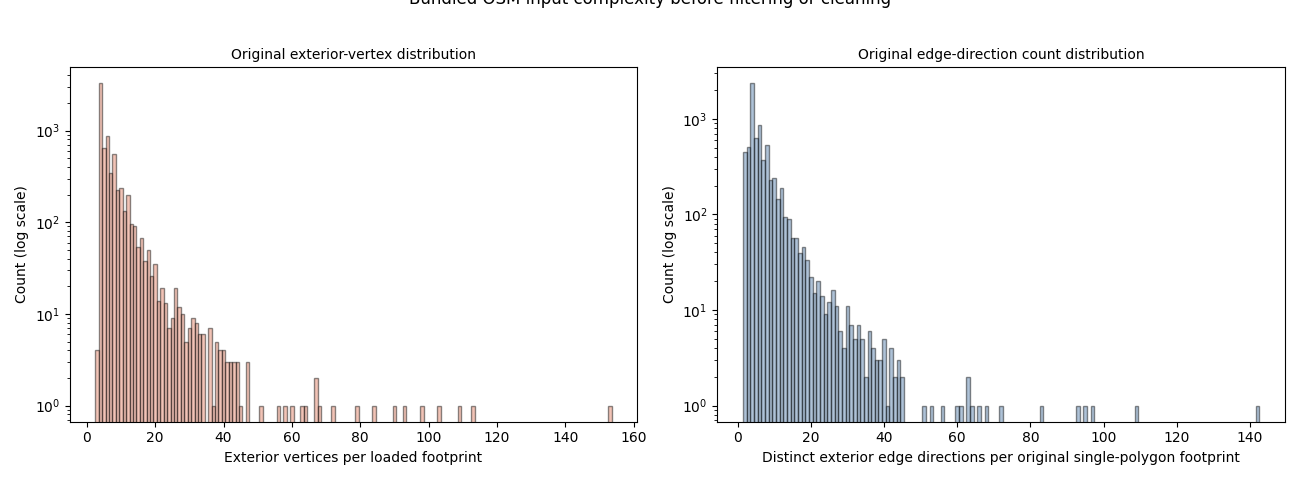

Original loaded footprints: 7140
Single-polygon inputs used for raw direction-count histogram: 7126
Multipart inputs excluded only from raw direction-count histogram: 14
Original input summary:
       n_vertices_original  n_unique_directions_original
count          7140.000000                   7126.000000
mean              7.092437                      6.797081
std               6.422608                      6.153459
min               3.000000                      2.000000
25%               4.000000                      4.000000
50%               5.000000                      5.000000
75%               8.000000                      8.000000
max             153.000000                    142.000000


In [3]:
raw_input_df = buildings_gdf[['sample_id', 'geometry']].copy()
raw_input_df['n_vertices_original'] = raw_input_df['geometry'].apply(count_exterior_vertices)
raw_polygon_input_df = raw_input_df.loc[raw_input_df.geometry.geom_type == 'Polygon'].copy()
raw_polygon_input_df['n_unique_directions_original'] = raw_polygon_input_df['geometry'].apply(lambda geom: count_exterior_direction_groups(geom, angle_tol_deg=0.0))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
vertex_min = int(raw_input_df['n_vertices_original'].min())
vertex_max = int(raw_input_df['n_vertices_original'].max())
vertex_bins = np.arange(vertex_min - 0.5, vertex_max + 1.5, 1.0)
direction_min = int(raw_polygon_input_df['n_unique_directions_original'].min()) if not raw_polygon_input_df.empty else 0
direction_max = int(raw_polygon_input_df['n_unique_directions_original'].max()) if not raw_polygon_input_df.empty else 0
direction_bins = np.arange(direction_min - 0.5, direction_max + 1.5, 1.0) if direction_max >= direction_min else np.array([-0.5, 0.5])

axes[0].hist(raw_input_df['n_vertices_original'], bins=vertex_bins, color='#e07a5f', alpha=0.45, edgecolor='black')
axes[0].set_yscale('log')
axes[0].set_title('Original exterior-vertex distribution')
axes[0].set_xlabel('Exterior vertices per loaded footprint')
axes[0].set_ylabel('Count (log scale)')

if raw_polygon_input_df.empty:
    axes[1].text(0.5, 0.5, 'No single-polygon inputs available', ha='center', va='center')
    axes[1].axis('off')
else:
    axes[1].hist(raw_polygon_input_df['n_unique_directions_original'], bins=direction_bins, color='#4c78a8', alpha=0.45, edgecolor='black')
    axes[1].set_yscale('log')
    axes[1].set_title('Original edge-direction count distribution')
    axes[1].set_xlabel('Distinct exterior edge directions per original single-polygon footprint')
    axes[1].set_ylabel('Count (log scale)')

fig.suptitle('Bundled OSM input complexity before filtering or cleaning', y=1.02)
plt.tight_layout()
plt.show()

print('Original loaded footprints:', len(raw_input_df))
print('Single-polygon inputs used for raw direction-count histogram:', len(raw_polygon_input_df))
print('Multipart inputs excluded only from raw direction-count histogram:', len(raw_input_df) - len(raw_polygon_input_df))
print('Original input summary:')
if raw_polygon_input_df.empty:
    print(raw_input_df[['n_vertices_original']].describe().to_string())
else:
    print(
        pd.concat([
            raw_input_df[['n_vertices_original']].describe(),
            raw_polygon_input_df[['n_unique_directions_original']].describe(),
        ], axis=1).to_string()
    )


## Remove weird shapes

### Keep only single-polygon buildings

**Inputs**
- Raw sampled `buildings_gdf` loaded from `data/osm/osm_building_footprints_openstreetmap_odbl.gpkg`

**Steps**
1. Count geometry types before any filtering.
2. Collect the discarded non-`Polygon` rows for manual review.
3. Keep only `Polygon` buildings for the downstream preprocessing pipeline.
4. Preserve the retained single-polygon geometry as `geometry_raw` for later stage-by-stage comparisons.

**Outputs**
- Filtered `buildings_gdf`
- `discarded_multipolygon_gdf` for inspection


In [4]:
geom_counts_before = buildings_gdf.geom_type.value_counts(dropna=False)

discarded_multipolygon_gdf = buildings_gdf.loc[buildings_gdf.geom_type != 'Polygon'].copy().reset_index(drop=True)
discarded_multipolygon_gdf['n_polygon_parts'] = discarded_multipolygon_gdf.geometry.apply(
    lambda geom: len(list(getattr(geom, 'geoms', []))) if geom is not None and not getattr(geom, 'is_empty', True) else 0
)

buildings_gdf = buildings_gdf.loc[buildings_gdf.geom_type == 'Polygon'].copy().reset_index(drop=True)
buildings_gdf['geometry_raw'] = buildings_gdf.geometry.copy()

print('Geometry types before filtering:')
print(geom_counts_before.to_string())
print('Discarded non-Polygon rows:', len(discarded_multipolygon_gdf))
print('Rows after keeping Polygon only:', len(buildings_gdf))


Geometry types before filtering:
Polygon         7126
MultiPolygon      14
Discarded non-Polygon rows: 14
Rows after keeping Polygon only: 7126


### Plot discarded multipolygon buildings
Review a few discarded multipart footprints before the main preprocessing starts.


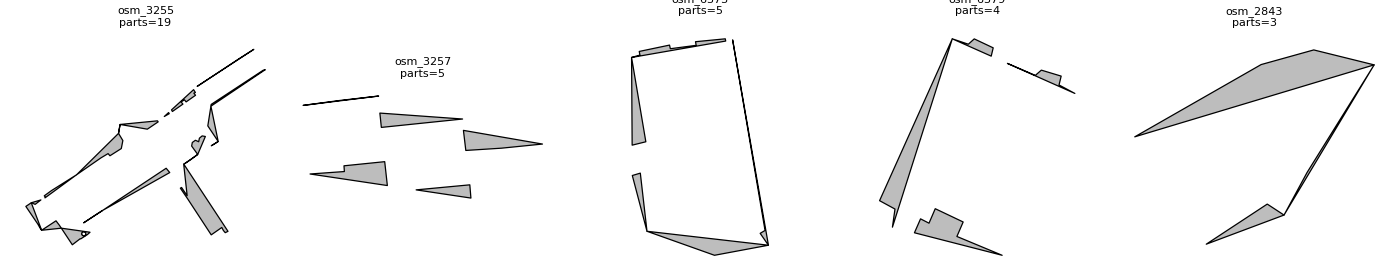

In [5]:
N_SHOW_MULTIPOLYGONS = 5
discarded_mp_plot_gdf = discarded_multipolygon_gdf.sort_values(['n_polygon_parts', 'sample_id'], ascending=[False, True]).head(N_SHOW_MULTIPOLYGONS).copy()

if discarded_mp_plot_gdf.empty:
    print('No discarded multipolygon buildings in the sampled dataset.')
else:
    plot_ids = discarded_mp_plot_gdf['sample_id'].tolist()
    GHSL_gridplot([{'name': 'discarded_multipolygons', 'gdf': discarded_mp_plot_gdf, 'role': 'main', 'id_col': 'sample_id', 'geometry_col': 'geometry', 'color': '#bdbdbd', 'edgecolor': 'black', 'linewidth': 0.9}], ids=plot_ids, ncols=min(5, len(plot_ids)), figsize_scale=2.8, title_fn=lambda sid, i: f"{sid}\nparts={int(discarded_mp_plot_gdf.iloc[i]['n_polygon_parts'])}")


### Flag and remove obvious linear artifacts

**Inputs**
- Single-polygon `buildings_gdf` after multipart filtering

**Steps**
1. Configure conservative width and aspect-ratio thresholds for wall-like artifacts.
2. Flag hard-drop and review candidates.
3. Print the hard-drop candidates and review ids for inspection.
4. Remove only the hard-drop artifacts from `buildings_gdf`.

**Outputs**
- Filtered `buildings_gdf`
- `ARTIFACT_FILTER_CFG`
- `hard_drop_df` and `review_df`


In [6]:
ARTIFACT_FILTER_CFG = LinearArtifactFilterConfig(
    hard_min_width_m=2.0,
    hard_min_aspect_ratio=8.0,
    review_min_width_m=3.0,
    review_min_aspect_ratio=6.0,
)

buildings_gdf = annotate_linear_artifact_flags(buildings_gdf, geometry_col='geometry', cfg=ARTIFACT_FILTER_CFG)

hard_drop_df = buildings_gdf.loc[buildings_gdf['is_linear_artifact_hard']].copy()
# Review-only cases stay in the table so the user can drop them manually after inspection.
review_df = buildings_gdf.loc[buildings_gdf['is_linear_artifact_review']].copy()

print('Linear-artifact summary:')
print(f"Hard-drop candidates: {len(hard_drop_df)}")
print(f"Review candidates: {len(review_df)}")
if not review_df.empty:
    review_ids = review_df.sort_values(['artifact_mrr_width_m', 'artifact_aspect_ratio'])['sample_id'].tolist()
    print('Review candidate ids:')
    print(review_ids)

if not hard_drop_df.empty:
    print('Hard-drop candidates:')
    print(hard_drop_df[['sample_id', 'artifact_mrr_width_m', 'artifact_mrr_length_m', 'artifact_aspect_ratio', 'artifact_rect_fill']].sort_values(['artifact_mrr_width_m', 'artifact_aspect_ratio']).to_string(index=False))

buildings_gdf = buildings_gdf.loc[~buildings_gdf['is_linear_artifact_hard']].copy().reset_index(drop=True)
print('Rows after removing hard-drop linear artifacts:', len(buildings_gdf))


Linear-artifact summary:
Hard-drop candidates: 6
Review candidates: 11
Review candidate ids:
['osm_5503', 'osm_2406', 'osm_3260', 'osm_2985', 'osm_3639', 'osm_5833', 'osm_4023', 'osm_5280', 'osm_6376', 'osm_1478', 'osm_2742']
Hard-drop candidates:
sample_id  artifact_mrr_width_m  artifact_mrr_length_m  artifact_aspect_ratio  artifact_rect_fill
 osm_4253              0.147979               8.809065              59.529334            0.928846
 osm_1756              0.820127              12.973106              15.818411            0.909941
 osm_0033              1.091145             100.143561              91.778457            0.847906
 osm_4234              1.269228              22.662371              17.855236            0.997367
 osm_4163              1.337092              11.621493               8.691616            0.610621
 osm_5668              1.951029              19.175988               9.828655            0.980663
Rows after removing hard-drop linear artifacts: 7120


### Plot the hard-drop linear artifacts
Visualize the narrowest strip-like footprints that will be removed before the subset is built.

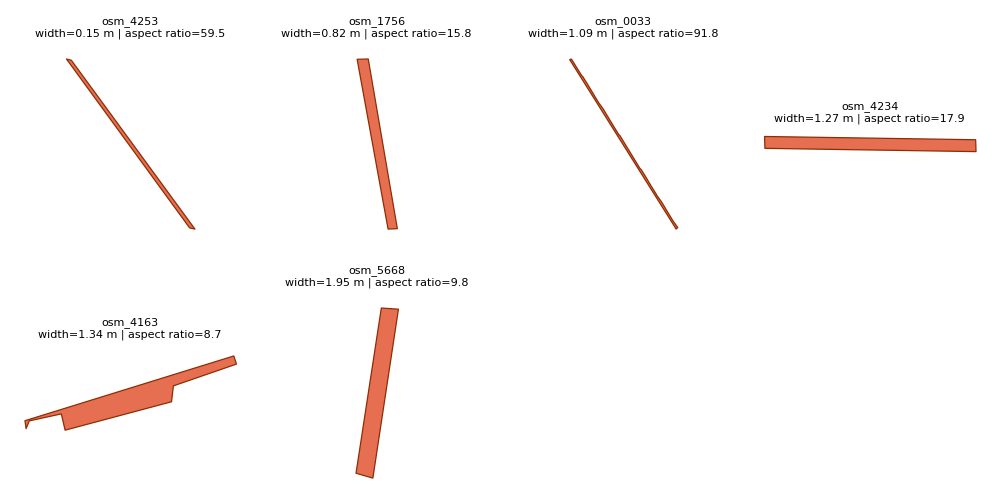

In [7]:
N_SHOW_ARTIFACTS = 12
artifact_plot_gdf = hard_drop_df.sort_values(['artifact_mrr_width_m', 'artifact_aspect_ratio']).head(N_SHOW_ARTIFACTS).copy()

if artifact_plot_gdf.empty:
    print('No hard-drop linear artifacts under the current thresholds.')
else:
    GHSL_gridplot([{'name': 'artifact_candidates', 'gdf': artifact_plot_gdf, 'role': 'main', 'id_col': 'sample_id', 'geometry_col': 'geometry', 'color': '#e76f51', 'edgecolor': '#8c2d04', 'linewidth': 0.9}], ids=artifact_plot_gdf['sample_id'].tolist(), ncols=4, figsize_scale=2.5, title_fn=lambda sid, i: f"{sid}\nwidth={artifact_plot_gdf.iloc[i]['artifact_mrr_width_m']:.2f} m | aspect ratio={artifact_plot_gdf.iloc[i]['artifact_aspect_ratio']:.1f}")


### Plot the linear artifacts to be reviewed
Visualize the review subset to decide if any should be dropped as well.

Review-only linear-artifact ids for copy/paste:
['osm_5503', 'osm_2406', 'osm_3260', 'osm_2985', 'osm_3639', 'osm_5833', 'osm_4023', 'osm_5280', 'osm_6376', 'osm_1478', 'osm_2742']


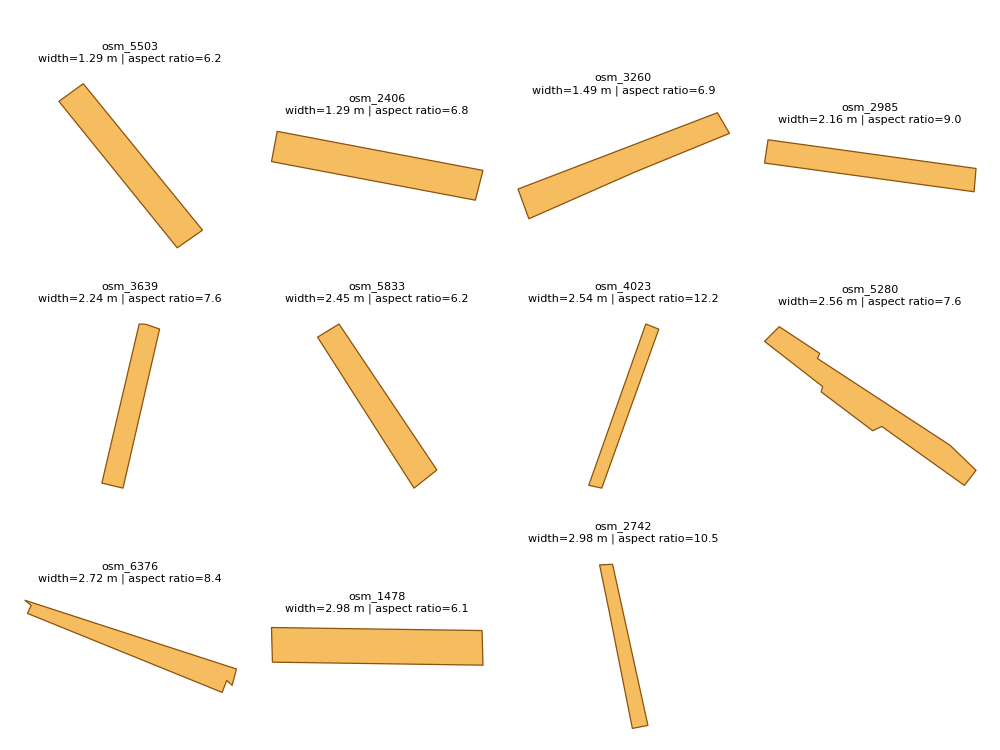

In [8]:
N_SHOW_REVIEW_ARTIFACTS = 12
review_plot_gdf = review_df.sort_values(['artifact_mrr_width_m', 'artifact_aspect_ratio']).head(N_SHOW_REVIEW_ARTIFACTS).copy()

if review_plot_gdf.empty:
    print('No review-only linear-artifact candidates under the current thresholds.')
else:
    print('Review-only linear-artifact ids for copy/paste:')
    print(review_plot_gdf['sample_id'].tolist())
    GHSL_gridplot(
        [
            {
                'name': 'artifact_review_candidates',
                'gdf': review_plot_gdf,
                'role': 'main',
                'id_col': 'sample_id',
                'geometry_col': 'geometry',
                'color': '#f6bd60',
                'edgecolor': '#8c510a',
                'linewidth': 0.9,
            }
        ],
        ids=review_plot_gdf['sample_id'].tolist(),
        ncols=4,
        figsize_scale=2.5,
        title_fn=lambda sid, i: f"{sid}\nwidth={review_plot_gdf.iloc[i]['artifact_mrr_width_m']:.2f} m | aspect ratio={review_plot_gdf.iloc[i]['artifact_aspect_ratio']:.1f}",
    )

# REVIEW_DROP_SAMPLE_IDS = ['osm_0001', 'osm_0002']
# if REVIEW_DROP_SAMPLE_IDS:
#     buildings_gdf = buildings_gdf.loc[~buildings_gdf['sample_id'].isin(REVIEW_DROP_SAMPLE_IDS)].copy().reset_index(drop=True)
#     review_df = review_df.loc[~review_df['sample_id'].isin(REVIEW_DROP_SAMPLE_IDS)].copy().reset_index(drop=True)
#     print('Rows after manual review drops:', len(buildings_gdf))


### Count holes and remove over-holed footprints

**Inputs**
- Artifact-filtered `buildings_gdf`

**Steps**
1. Set the maximum allowed hole count.
2. Count holes for each retained polygon.
3. Collect the over-holed buildings for review.
4. Remove footprints with more than `MAX_ALLOWED_HOLES` holes before subset sampling.

**Outputs**
- Updated `buildings_gdf` with `n_holes`
- `too_many_holes_df`
- `MAX_ALLOWED_HOLES`


In [9]:
MAX_ALLOWED_HOLES = 4

buildings_gdf['n_holes'] = buildings_gdf.geometry.apply(count_polygon_holes)
too_many_holes_df = buildings_gdf.loc[buildings_gdf['n_holes'] > MAX_ALLOWED_HOLES].copy()

print('Excessive-hole summary:')
print(f"Removed candidates (> {MAX_ALLOWED_HOLES} holes): {len(too_many_holes_df)}")

if not too_many_holes_df.empty:
    print('Removed excessive-hole candidates:')
    print(too_many_holes_df[['sample_id', 'n_holes']].sort_values(['n_holes', 'sample_id'], ascending=[False, True]).to_string(index=False))

buildings_gdf = buildings_gdf.loc[buildings_gdf['n_holes'] <= MAX_ALLOWED_HOLES].copy().reset_index(drop=True)
print('Rows after removing excessive-hole buildings:', len(buildings_gdf))


Excessive-hole summary:
Removed candidates (> 4 holes): 3
Removed excessive-hole candidates:
sample_id  n_holes
 osm_2934        9
 osm_1729        6
 osm_2390        6
Rows after removing excessive-hole buildings: 7117


### Plot discarded excessive-hole buildings
Review a few removed footprints with many atriums or internal courtyards.


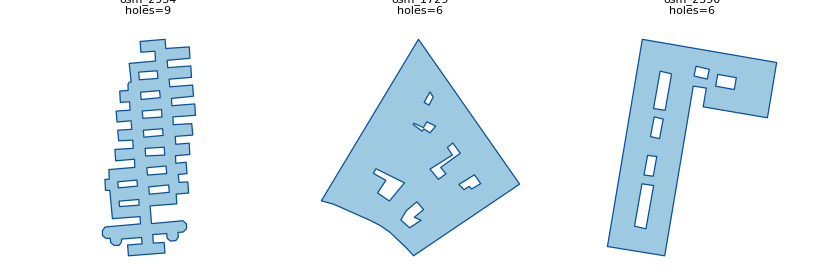

In [10]:
N_SHOW_HOLES = 5
too_many_holes_plot_gdf = too_many_holes_df.sort_values(['n_holes', 'sample_id'], ascending=[False, True]).head(N_SHOW_HOLES).copy()

if too_many_holes_plot_gdf.empty:
    print('No excessive-hole buildings under the current threshold.')
else:
    plot_ids = too_many_holes_plot_gdf['sample_id'].tolist()
    GHSL_gridplot([{'name': 'too_many_holes', 'gdf': too_many_holes_plot_gdf, 'role': 'main', 'id_col': 'sample_id', 'geometry_col': 'geometry', 'color': '#9ecae1', 'edgecolor': '#08519c', 'linewidth': 0.9}], ids=plot_ids, ncols=min(5, len(plot_ids)), figsize_scale=2.8, title_fn=lambda sid, i: f"{sid}\nholes={int(too_many_holes_plot_gdf.iloc[i]['n_holes'])}")


## Geometry cleaning

### Normalize footprint geometries and integrate the final edge regularization

**Inputs**
- Single-polygon `buildings_gdf`

**Steps**
1. Configure a conservative footprint normalizer with simplification, snapping, short-edge cleanup, and almost-collinear cleanup thresholds.
2. Configure the same conservative multi-family edge regularizer that used to run as a separate step.
3. Apply normalization first, then reuse the integrated line-clustering pass only on the cleaned footprints.
4. Record vertex, area, and angle-family diagnostics so both effects can still be inspected explicitly.

**Outputs**
- Cleaned `buildings_gdf`
- `NORMALIZATION_CFG` and `EDGE_ALIGNMENT_CFG`
- Diagnostic columns such as `geometry_before_norm`, `geometry_before_align`, `vertex_delta_norm`, `vertex_delta_align`, and `n_angle_families_align`


In [11]:
NORMALIZATION_CFG = FootprintNormalizationConfig(
    simplify_tolerance_m=0.2,
    snap_tolerance_m=0.05,
    min_edge_length_m=0.75,
    collinear_distance_tol_m=0.3,
    collinear_angle_tol_deg=10.0,
    area_change_ratio_tol=0.03,
    area_change_m2_tol=3.0,
    max_passes=8,
)
buildings_gdf = normalize_buildings_gdf(
    buildings_gdf,
    geometry_col='geometry',
    cfg=NORMALIZATION_CFG,
    align_cfg=EDGE_ALIGNMENT_CFG,
)

n_changed = int((buildings_gdf['vertex_delta_norm'] != 0).sum())
mean_vertex_delta = float(buildings_gdf['vertex_delta_norm'].mean())
max_area_delta = float(buildings_gdf['area_delta_norm_m2'].abs().max())
n_align_changed = int(buildings_gdf['alignment_changed'].sum())
mean_align_vertex_delta = float(buildings_gdf['vertex_delta_align'].mean())
max_align_area_delta = float(buildings_gdf['area_delta_align_m2'].abs().max())
mean_angle_families = float(buildings_gdf['n_angle_families_align'].mean())
max_angle_families = int(buildings_gdf['n_angle_families_align'].max())

print('Normalization summary:')
print(f'Changed footprints: {n_changed} / {len(buildings_gdf)}')
print(f'Mean vertex delta: {mean_vertex_delta:.2f}')
print(f'Max absolute area delta: {max_area_delta:.3f} m²')
print('')
print('Integrated edge-regularization summary:')
print(f'Changed footprints: {n_align_changed} / {len(buildings_gdf)}')
print(f'Mean vertex delta: {mean_align_vertex_delta:.2f}')
print(f'Max absolute area delta: {max_align_area_delta:.3f} m²')
print(f'Mean detected angle families: {mean_angle_families:.2f}')
print(f'Max detected angle families: {max_angle_families}')

buildings_gdf[['sample_id', 'n_vertices_before_norm', 'n_vertices_after_norm', 'vertex_delta_norm', 'n_vertices_before_align', 'n_vertices_after_align', 'vertex_delta_align', 'area_delta_align_m2']].sort_values(['vertex_delta_norm', 'vertex_delta_align', 'area_delta_align_m2']).head(12)


Normalization summary:
Changed footprints: 2075 / 7117
Mean vertex delta: -0.62
Max absolute area delta: 18.451 m²

Integrated edge-regularization summary:
Changed footprints: 3001 / 7117
Mean vertex delta: -0.00
Max absolute area delta: 26.620 m²
Mean detected angle families: 2.94
Max detected angle families: 28


,sample_id,n_vertices_before_norm,n_vertices_after_norm,vertex_delta_norm,n_vertices_before_align,n_vertices_after_align,vertex_delta_align,area_delta_align_m2
1691,osm_1694,113,65,-48,65,65,0,-1.149721e-01
1702,osm_1705,60,25,-35,25,25,0,-4.284352e-02
4285,osm_4302,93,68,-25,68,68,0,-1.216543e+00
4417,osm_4434,33,14,-19,14,14,0,2.720416e-04
2094,osm_2099,153,134,-19,134,134,0,2.861150e-01
1432,osm_1435,67,49,-18,49,49,0,-1.372821e+00
5712,osm_5731,31,14,-17,14,14,0,2.296196e-01
2489,osm_2496,20,4,-16,4,4,0,0.000000e+00
3378,osm_3391,63,48,-15,48,48,0,-2.181893e+00
5555,osm_5573,21,6,-15,6,6,0,-2.094447e-03


### Plot the strongest footprint simplifications
Overlay the normalized footprints on top of their original geometry for the buildings with the largest vertex reductions.

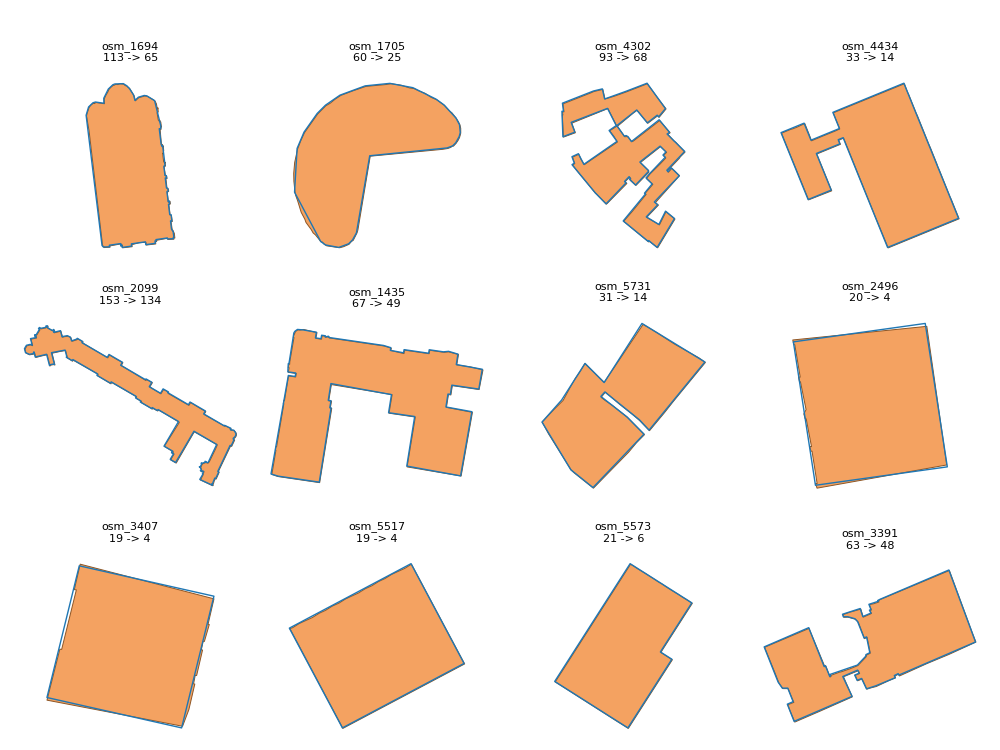

In [12]:
N_SHOW_NORM = 12
changed_plot_gdf = buildings_gdf.loc[buildings_gdf['vertex_delta_norm'] < 0].copy().sort_values(['vertex_delta_norm', 'n_vertices_before_norm', 'area_before_norm_m2']).head(N_SHOW_NORM)

if changed_plot_gdf.empty:
    print('No buildings were simplified under the current normalization settings.')
else:
    before_gdf = gpd.GeoDataFrame(changed_plot_gdf.copy(), geometry='geometry_before_norm', crs=buildings_gdf.crs)
    after_gdf = gpd.GeoDataFrame(changed_plot_gdf.copy(), geometry='geometry', crs=buildings_gdf.crs)
    plot_ids = changed_plot_gdf['sample_id'].tolist()
    GHSL_gridplot([
        {'name': 'before_norm', 'gdf': before_gdf, 'role': 'main', 'id_col': 'sample_id', 'geometry_col': 'geometry_before_norm', 'color': '#f4a261', 'edgecolor': '#8d5524', 'linewidth': 0.7},
        {'name': 'after_norm', 'gdf': after_gdf, 'role': 'main', 'id_col': 'sample_id', 'geometry_col': 'geometry', 'color': 'none', 'edgecolor': '#1f77b4', 'linewidth': 1.0, 'zorder': 3},
    ], ids=plot_ids, ncols=4, figsize_scale=2.5, title_fn=lambda sid, i: f"{sid}\n{int(changed_plot_gdf.iloc[i]['n_vertices_before_norm'])} -> {int(changed_plot_gdf.iloc[i]['n_vertices_after_norm'])}")


### Plot footprints changed by the integrated edge regularization
Overlay the cleaned footprints on top of their pre-alignment geometry twice: first with all inferred axes shown in dashed black before grouping, then with the same axes colored by their matched angle families.


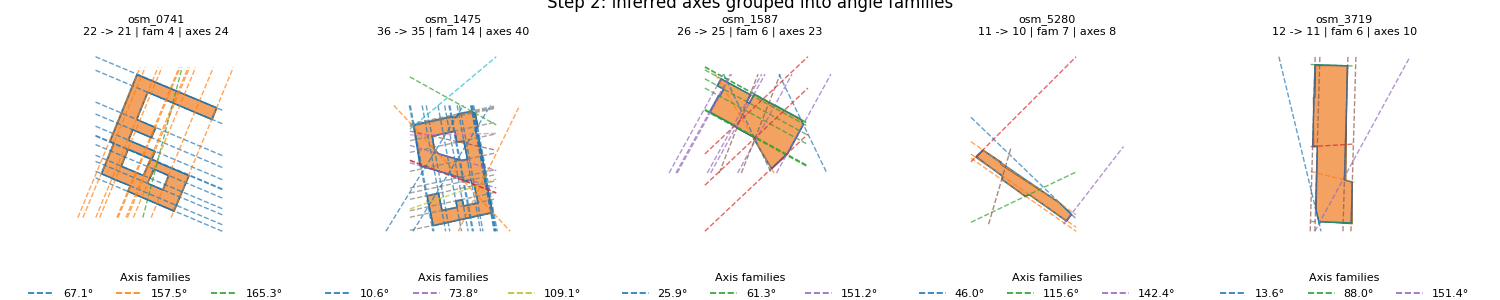

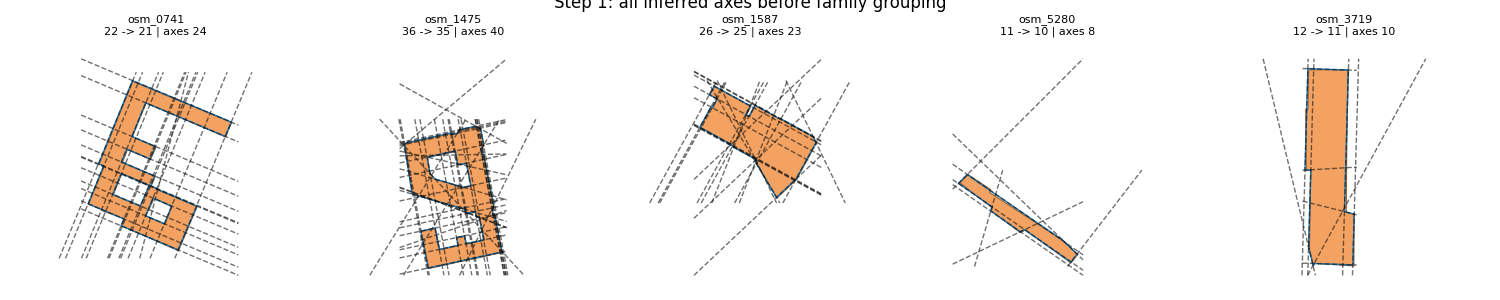

In [13]:
N_SHOW_ALIGN = 5
aligned_plot_gdf = buildings_gdf.loc[buildings_gdf['alignment_changed']].copy().sort_values(
    ['vertex_delta_align', 'area_delta_align_m2', 'n_vertices_before_align'],
    ascending=[True, False, False],
).head(N_SHOW_ALIGN)

plot_alignment_family_showcase(aligned_plot_gdf, buildings_gdf, EDGE_ALIGNMENT_CFG)


## Build the OSM decomposition working set

### Select the final decomposition subset

**Inputs**
- Cleaned `buildings_gdf`

**Steps**
1. Compute `area_m2` and `n_vertices` from the cleaned geometry.
2. Mark the footprints that remain non-convex after preprocessing.
3. Retain only the still non-convex footprints with 6 to 32 exterior vertices, matching the OSM working-set definition reported in the paper.
4. Summarize how many preprocessed non-convex footprints are available and selected in each exact vertex-count bucket.

**Outputs**
- `subset_buildings_gdf`
- `subset_counts_df`


In [14]:
buildings_gdf['area_m2'] = buildings_gdf.geometry.area.astype(float)
buildings_gdf['n_vertices'] = buildings_gdf.geometry.apply(count_exterior_vertices)
buildings_gdf['is_convex_after_preprocess'] = buildings_gdf.geometry.apply(is_convex_polygon)

keep_cols = ['sample_id', 'geometry', 'area_m2', 'n_vertices', 'n_holes']
missing_cols = [col for col in keep_cols if col not in buildings_gdf.columns]
if missing_cols:
    raise KeyError(f'Missing expected columns in buildings_gdf: {missing_cols}')

preprocessed_nonconvex_gdf = buildings_gdf.loc[~buildings_gdf['is_convex_after_preprocess']].copy()
preprocessed_nonconvex_gdf['selected_for_subset'] = preprocessed_nonconvex_gdf['n_vertices'].between(6, 32)

subset_buildings_gdf = gpd.GeoDataFrame(
    preprocessed_nonconvex_gdf.loc[preprocessed_nonconvex_gdf['selected_for_subset'], keep_cols].copy(),
    geometry='geometry',
    crs=buildings_gdf.crs,
)
subset_counts_df = (
    preprocessed_nonconvex_gdf.groupby('n_vertices', as_index=False)
    .agg(
        n_available=('sample_id', 'size'),
        n_selected=('selected_for_subset', 'sum'),
    )
    .sort_values('n_vertices')
    .reset_index(drop=True)
)
subset_counts_df['n_selected'] = subset_counts_df['n_selected'].astype(int)
subset_counts_df['n_excluded'] = subset_counts_df['n_available'] - subset_counts_df['n_selected']

print('Rows after preprocessing:', len(buildings_gdf))
print('Still non-convex after preprocessing:', len(preprocessed_nonconvex_gdf))
print('Selected for decomposition subset (6-32 exterior vertices):', len(subset_buildings_gdf))
print('Excluded by the 6-32 vertex filter:', int((~preprocessed_nonconvex_gdf['selected_for_subset']).sum()))
if not subset_buildings_gdf.empty:
    print('Selected vertex range:', f"{int(subset_buildings_gdf['n_vertices'].min())}-{int(subset_buildings_gdf['n_vertices'].max())}")
print('Selected subset rule: retain still non-convex preprocessed footprints with 6-32 exterior vertices.')
subset_counts_df


Rows after preprocessing: 7117
Still non-convex after preprocessing: 2891
Selected for decomposition subset (6-32 exterior vertices): 2755
Excluded by the 6-32 vertex filter: 136
Selected vertex range: 6-32
Selected subset rule: retain still non-convex preprocessed footprints with 6-32 exterior vertices.


,n_vertices,n_available,n_selected,n_excluded
0,4,16,0,16
1,5,71,0,71
2,6,979,979,0
3,7,132,132,0
4,8,598,598,0
5,9,126,126,0
6,10,231,231,0
7,11,65,65,0
8,12,209,209,0
9,13,50,50,0


## Inspection and saving


### Plot the selected decomposition subset across the retained vertex-count range
Inspect one selected example from evenly spaced non-empty vertex-count buckets in the final 6-32 vertex working set.


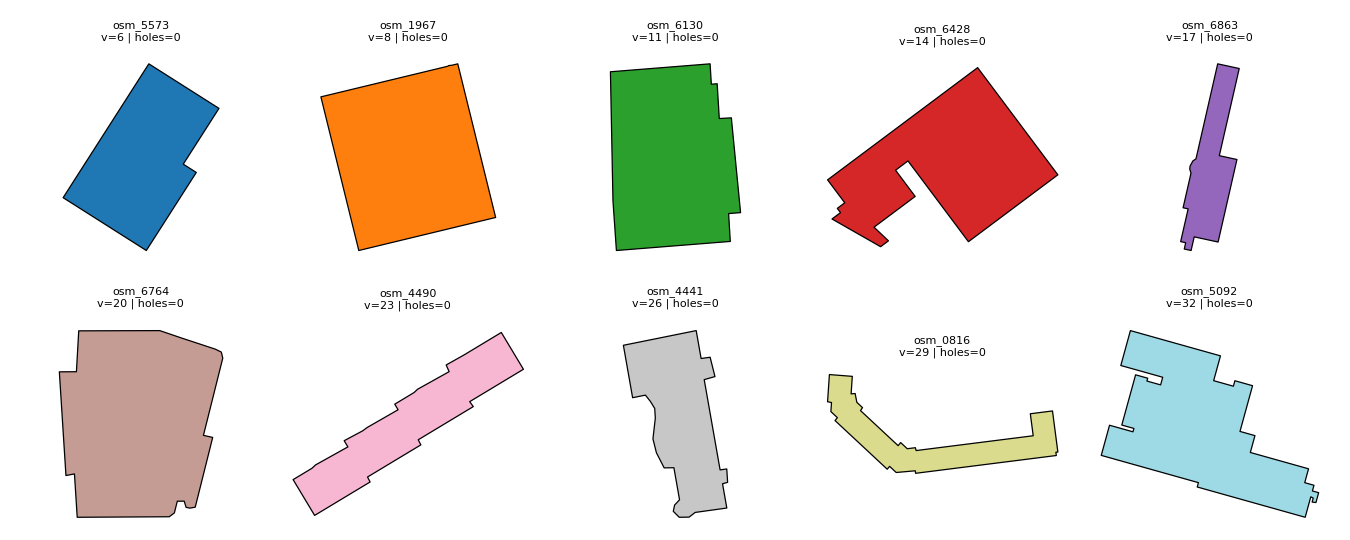

In [15]:
N_SHOW_VERTEX_BUCKETS = 10
non_empty_buckets = subset_counts_df.loc[subset_counts_df['n_selected'] > 0, 'n_vertices'].tolist()
subset_lookup = subset_buildings_gdf.set_index('sample_id')

if not non_empty_buckets:
    print('No non-empty vertex-count buckets in the selected decomposition subset.')
else:
    bucket_indices = np.unique(
        np.linspace(0, len(non_empty_buckets) - 1, num=min(N_SHOW_VERTEX_BUCKETS, len(non_empty_buckets)), dtype=int)
    )
    selected_buckets = [non_empty_buckets[idx] for idx in bucket_indices]
    colors = cmaps['tab20'](np.linspace(0.0, 1.0, len(selected_buckets)))
    subset_sources = []
    plot_ids = []
    for color, n_vertices in zip(colors, selected_buckets):
        g_bucket = subset_buildings_gdf.loc[subset_buildings_gdf['n_vertices'] == n_vertices].sort_values(
            ['area_m2', 'sample_id'], ascending=[False, True]
        ).head(1).copy()
        if g_bucket.empty:
            continue
        plot_ids.extend(g_bucket['sample_id'].tolist())
        subset_sources.append({
            'name': f'v_{n_vertices}',
            'gdf': g_bucket,
            'role': 'main',
            'id_col': 'sample_id',
            'geometry_col': 'geometry',
            'color': tuple(color),
            'edgecolor': 'black',
            'linewidth': 0.9,
        })

    GHSL_gridplot(
        subset_sources,
        ids=plot_ids,
        ncols=min(5, len(plot_ids)),
        figsize_scale=2.7,
        title_fn=lambda sid, i: f"{sid}\nv={int(subset_lookup.loc[sid, 'n_vertices'])} | holes={int(subset_lookup.loc[sid, 'n_holes'])}",
    )


### Select representative footprints across the preprocessing stages
Pick three retained examples that stay readable in the stage-by-stage plots:
1. the most complex holed retained footprint that stays under the representative axis cap,
2. the most complex retained footprint overall that stays under the same cap,
3. one median-complexity retained footprint chosen to stay visually readable while still showing meaningful preprocessing.


In [16]:
N_REPRESENTATIVE_PLANS = 3
MAX_REPRESENTATIVE_AXES = 32
MAX_MEDIAN_REPRESENTATIVE_AXES = 16
representative_ids = []
selection_rows = []

# Restrict representative selection to the retained decomposition working set.
representative_meta = buildings_gdf.loc[buildings_gdf['sample_id'].isin(subset_buildings_gdf['sample_id'])].copy()
axis_diag_rows = []
for _, row in representative_meta.iterrows():
    _, axis_diag = alignment_axis_records_for_polygon(row.geometry, EDGE_ALIGNMENT_CFG)
    axis_diag_rows.append({
        'sample_id': row['sample_id'],
        'representative_axis_count': int(axis_diag['n_axes']),
        'representative_angle_family_count': int(axis_diag['n_angle_families']),
    })
representative_meta = representative_meta.merge(pd.DataFrame(axis_diag_rows), on='sample_id', how='left')
representative_meta['log_area_distance'] = (
    np.log10(representative_meta['area_m2'].clip(lower=1e-9))
    - np.log10(representative_meta['area_m2'].median())
).abs()

sorted_retained_df = representative_meta.sort_values(['n_vertices', 'area_m2'], ascending=[False, False]).reset_index(drop=True)

hole_candidates = sorted_retained_df.loc[
    (sorted_retained_df['n_holes'] > 0)
    & (sorted_retained_df['representative_axis_count'] <= MAX_REPRESENTATIVE_AXES)
]
if hole_candidates.empty:
    hole_candidates = sorted_retained_df.loc[sorted_retained_df['n_holes'] > 0]
if not hole_candidates.empty:
    selected_id = hole_candidates.iloc[0]['sample_id']
    representative_ids.append(selected_id)
    selection_rows.append({'sample_id': selected_id, 'why_selected': f'most complex holed retained footprint under the {MAX_REPRESENTATIVE_AXES}-axis readability cap'})

overall_candidates = sorted_retained_df.loc[sorted_retained_df['representative_axis_count'] <= MAX_REPRESENTATIVE_AXES]
if overall_candidates.empty:
    overall_candidates = sorted_retained_df
for sample_id in overall_candidates['sample_id']:
    if sample_id not in representative_ids:
        representative_ids.append(sample_id)
        selection_rows.append({'sample_id': sample_id, 'why_selected': f'most complex retained footprint under the {MAX_REPRESENTATIVE_AXES}-axis readability cap'})
        break

if not sorted_retained_df.empty:
    median_target = float(sorted_retained_df['n_vertices'].median())
    median_candidates = sorted_retained_df.loc[~sorted_retained_df['sample_id'].isin(representative_ids)].copy()
    median_candidates['vertex_distance'] = (median_candidates['n_vertices'] - median_target).abs()
    readable_median_candidates = median_candidates.loc[
        median_candidates['representative_axis_count'] <= MAX_MEDIAN_REPRESENTATIVE_AXES
    ].copy()
    if readable_median_candidates.empty:
        readable_median_candidates = median_candidates.loc[
            median_candidates['representative_axis_count'] <= MAX_REPRESENTATIVE_AXES
        ].copy()
    if readable_median_candidates.empty:
        readable_median_candidates = median_candidates
    if not readable_median_candidates.empty:
        readable_median_candidates = readable_median_candidates.sort_values(
            ['vertex_distance', 'vertex_delta_norm', 'representative_angle_family_count', 'representative_axis_count', 'log_area_distance', 'sample_id'],
            ascending=[True, True, True, True, True, True],
        )
        selected_id = readable_median_candidates.iloc[0]['sample_id']
        representative_ids.append(selected_id)
        selection_rows.append({'sample_id': selected_id, 'why_selected': f'median-complexity retained footprint ({median_target:.1f} vertices) chosen for readability and visible preprocessing'})

for sample_id in sorted_retained_df['sample_id']:
    if len(representative_ids) >= N_REPRESENTATIVE_PLANS:
        break
    if sample_id not in representative_ids:
        representative_ids.append(sample_id)
        selection_rows.append({'sample_id': sample_id, 'why_selected': 'fallback highest-vertex retained footprint'})

representative_ids = representative_ids[:N_REPRESENTATIVE_PLANS]
selection_df = (
    pd.DataFrame(selection_rows)
    .drop_duplicates('sample_id')
    .set_index('sample_id')
    .loc[representative_ids]
    .reset_index()
    .merge(
        representative_meta[['sample_id', 'n_vertices', 'n_holes', 'representative_axis_count', 'representative_angle_family_count', 'vertex_delta_norm', 'area_m2']],
        on='sample_id',
        how='left',
    )
)
print('Representative selection rationale:')
display(selection_df)

representative_df = representative_meta.set_index('sample_id').loc[representative_ids].reset_index()
representative_df['stage_raw'] = representative_df['geometry_before_norm']
representative_df['stage_normalized'] = representative_df['geometry_before_align']
# Both aligned stages use the same snapped geometry; only the axis overlay changes.
representative_df['stage_aligned_raw_axes'] = representative_df['geometry']
representative_df['stage_aligned_family_axes'] = representative_df['geometry']

representative_axis_rows = []
representative_axis_counts = {}
representative_family_counts = {}
for _, row in representative_df.iterrows():
    axis_records, axis_diag = alignment_axis_records_for_polygon(row['stage_aligned_family_axes'], EDGE_ALIGNMENT_CFG)
    representative_axis_counts[row['sample_id']] = int(axis_diag['n_axes'])
    representative_family_counts[row['sample_id']] = int(axis_diag['n_angle_families'])
    for axis_idx, record in enumerate(axis_records):
        representative_axis_rows.append({
            'sample_id': row['sample_id'],
            'axis_idx': axis_idx,
            'family_label': f"{record['family_angle_deg']:.1f}°",
            'family_angle_deg': float(record['family_angle_deg']),
            'geometry': record['geometry'],
        })

representative_axes_gdf = gpd.GeoDataFrame(representative_axis_rows, geometry='geometry', crs=buildings_gdf.crs) if representative_axis_rows else gpd.GeoDataFrame(
    columns=['sample_id', 'axis_idx', 'family_label', 'family_angle_deg', 'geometry'], geometry='geometry', crs=buildings_gdf.crs
)

representative_df[['sample_id', 'n_vertices', 'n_holes', 'representative_axis_count', 'representative_angle_family_count', 'area_m2']]


Representative selection rationale:


,sample_id,why_selected,n_vertices,n_holes,representative_axis_count,representative_angle_family_count,vertex_delta_norm,area_m2
0,osm_3345,most complex holed retained footprint under th...,25,3,32,2,-2,1780.360543
1,osm_5092,most complex retained footprint under the 32-a...,32,0,30,4,-2,3395.471664
2,osm_1256,median-complexity retained footprint (8.0 vert...,8,0,7,2,-14,199.614903


,sample_id,n_vertices,n_holes,representative_axis_count,representative_angle_family_count,area_m2
0,osm_3345,25,3,32,2,1780.360543
1,osm_5092,32,0,30,4,3395.471664
2,osm_1256,8,0,7,2,199.614903


### Plot representative preprocessing stages
Show the raw, normalized, and aligned versions of the retained footprints, including the two-step axis visualization: first all inferred axes in dashed black, then the same axes colored by matched angle family. The chosen representatives are capped for readability so the figure stays interpretable.


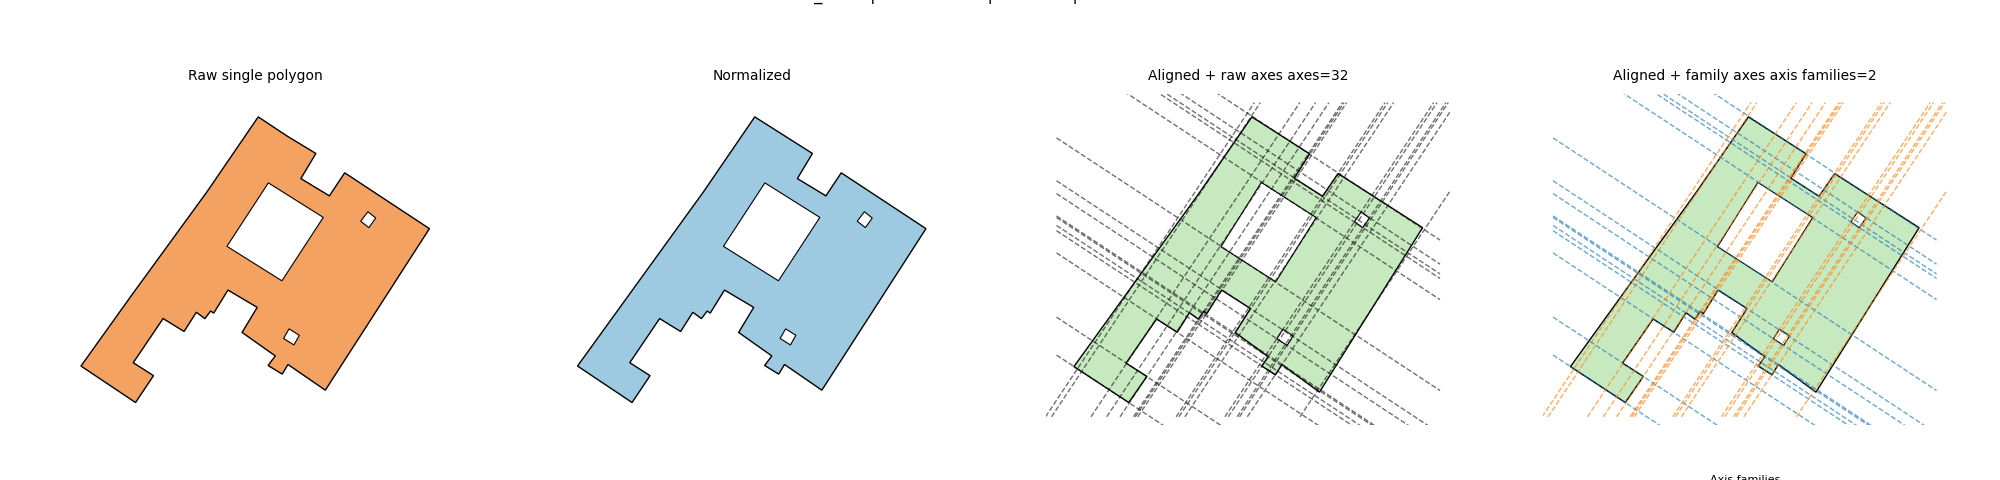

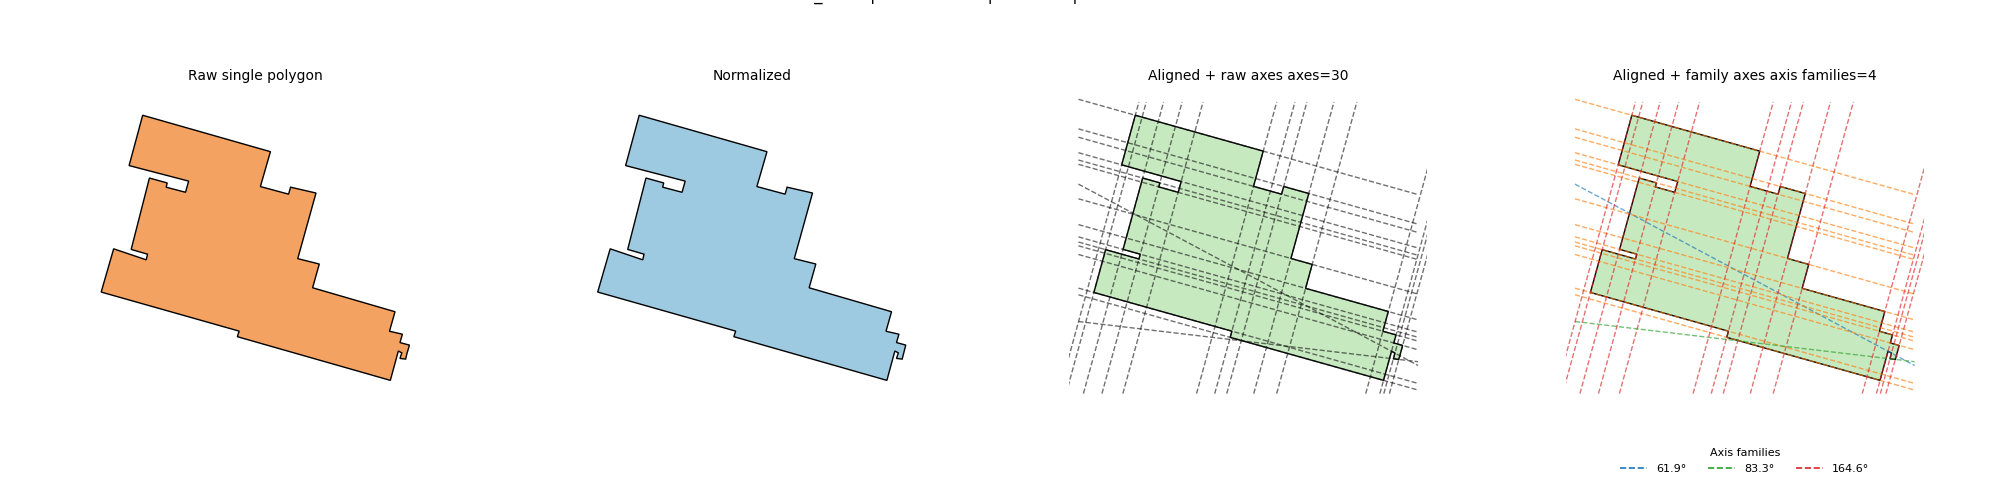

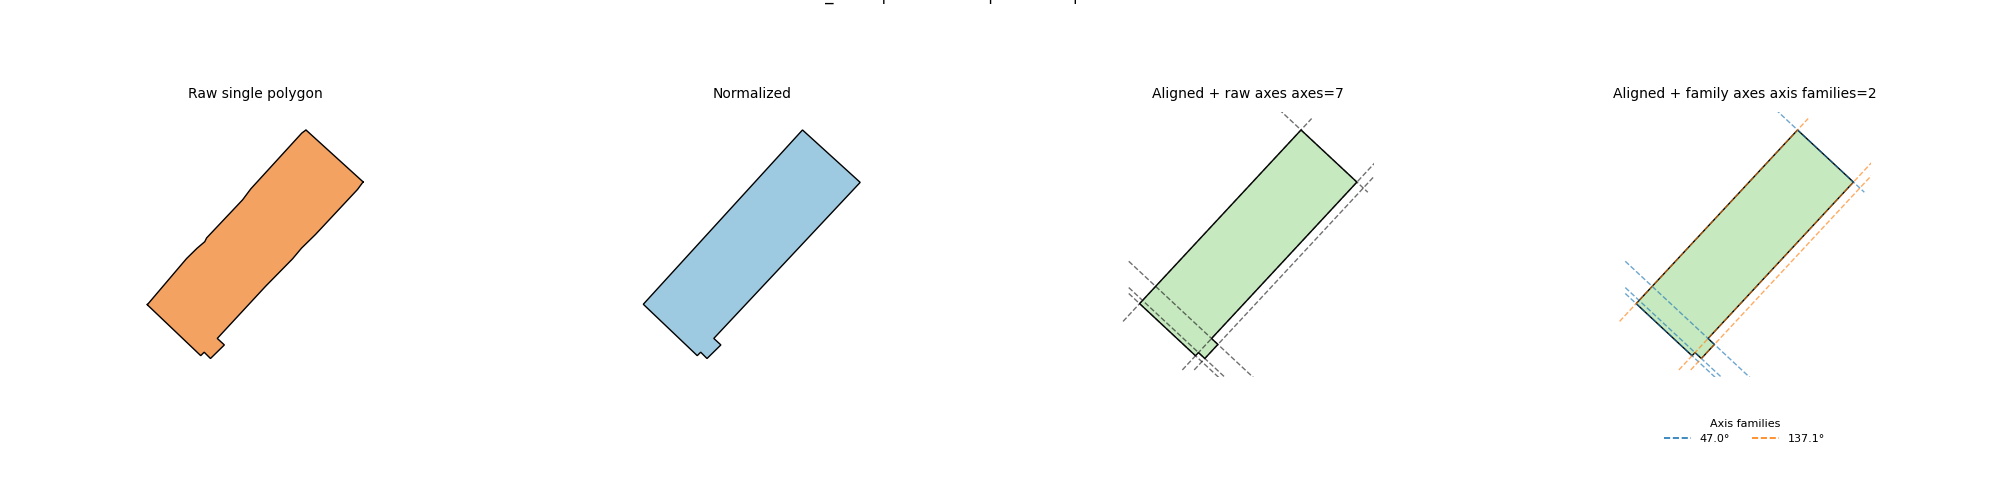

In [17]:
stage_specs = [
    ('Raw single polygon', 'stage_raw', '#f4a261', 'none'),
    ('Normalized', 'stage_normalized', '#9ecae1', 'none'),
    ('Aligned + raw axes', 'stage_aligned_raw_axes', '#c7e9c0', 'black'),
    ('Aligned + family axes', 'stage_aligned_family_axes', '#c7e9c0', 'family'),
]

for _, row in representative_df.iterrows():
    sample_id = row['sample_id']
    fig, axes = plt.subplots(1, len(stage_specs), figsize=(5 * len(stage_specs), 4.8))
    axes = np.atleast_1d(axes)
    # Reuse the axis records inferred from the aligned geometry in both overlay stages.
    family_slice = representative_axes_gdf.loc[representative_axes_gdf['sample_id'] == sample_id].copy() if not representative_axes_gdf.empty else gpd.GeoDataFrame(columns=representative_axes_gdf.columns, geometry='geometry', crs=representative_axes_gdf.crs)
    family_info = family_slice[['family_label', 'family_angle_deg']].drop_duplicates().sort_values('family_angle_deg').reset_index(drop=True) if not family_slice.empty else pd.DataFrame(columns=['family_label', 'family_angle_deg'])
    family_colors = {row['family_label']: tuple(cmaps['tab10'](idx % 10)) for idx, (_, row) in enumerate(family_info.iterrows())}
    family_handles = [Line2D([0], [0], color=family_colors[label], linestyle='--', linewidth=1.2, label=label) for label in family_info['family_label']]
    for ax, (stage_title, stage_col, facecolor, axis_mode) in zip(axes, stage_specs):
        geom = row[stage_col]
        fill_polygon_geometry(ax, geom, facecolor=facecolor)
        if axis_mode == 'black' and not family_slice.empty:
            family_slice.plot(ax=ax, color='#111111', linewidth=1.0, linestyle='--', alpha=0.6, zorder=10)
        elif axis_mode == 'family' and not family_slice.empty:
            for _, family_row in family_info.iterrows():
                label = family_row['family_label']
                family_geom = family_slice.loc[family_slice['family_label'] == label]
                family_geom.plot(ax=ax, color=family_colors[label], linewidth=1.0, linestyle='--', alpha=0.65, zorder=10)
        set_geometry_frame(ax, geom, min_pad=0.5, pad_ratio=0.08)
        if axis_mode == 'black':
            ax.set_title(f"{stage_title} axes={int(representative_axis_counts.get(sample_id, 0))}", pad=10)
        elif axis_mode == 'family':
            ax.set_title(f"{stage_title} axis families={int(representative_family_counts.get(sample_id, 0))}", pad=10)
            if family_handles:
                ax.legend(handles=family_handles, title='Axis families', loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=min(3, len(family_handles)), fontsize=8, title_fontsize=8, frameon=False, handlelength=2.4)
        else:
            ax.set_title(stage_title, pad=10)
    fig.suptitle(f"{sample_id} | vertices={int(row['n_vertices'])} | holes={int(row['n_holes'])} | area={row['area_m2']:.1f} m²", y=1.03)
    plt.tight_layout(rect=(0, 0.03, 1, 0.90), pad=1.0, h_pad=2.0, w_pad=1.0)
    plt.show()


### Plot the final working-set distributions
Show the two dataset-level distributions that define the final OSM decomposition working set written by this notebook. The first histogram counts exterior vertices per retained footprint after all filtering and geometric cleaning. The second counts distinct exterior edge directions per retained footprint, computed directly from the final footprint boundary after folding opposite directions into the same orientation range `0-180°`. The direction count is evaluated with `angle_tol_deg=0.0`, so no angular grouping is applied and the drop in direction counts reflects actual cleanup of boundary detail rather than family clustering. Both histograms use logarithmic count scales so the dominant low-complexity cases and the rarer complex cases remain visible together.


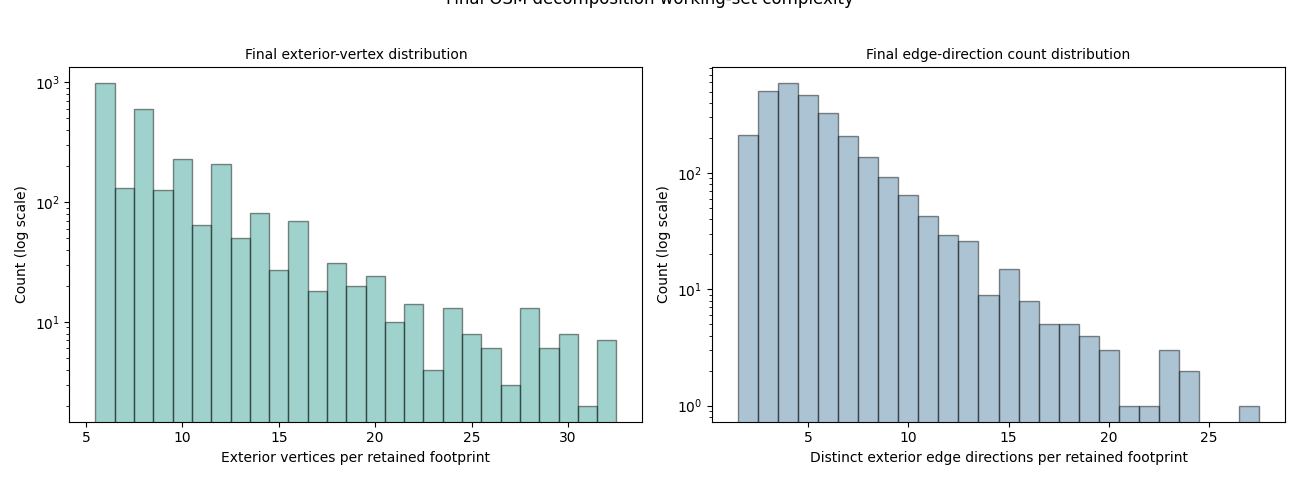

Final working-set summary:
        n_vertices  n_unique_directions_final
count  2755.000000                2755.000000
mean      9.330309                   5.354991
std       4.483627                   2.904734
min       6.000000                   2.000000
25%       6.000000                   3.000000
50%       8.000000                   5.000000
75%      10.500000                   6.000000
max      32.000000                  27.000000


In [18]:
final_subset_df = subset_buildings_gdf[['sample_id', 'geometry', 'n_vertices']].copy()
final_subset_df['n_unique_directions_final'] = final_subset_df['geometry'].apply(lambda geom: count_exterior_direction_groups(geom, angle_tol_deg=0.0))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
vertex_min = int(final_subset_df['n_vertices'].min())
vertex_max = int(final_subset_df['n_vertices'].max())
vertex_bins = np.arange(vertex_min - 0.5, vertex_max + 1.5, 1.0)
direction_min = int(final_subset_df['n_unique_directions_final'].min())
direction_max = int(final_subset_df['n_unique_directions_final'].max())
direction_bins = np.arange(direction_min - 0.5, direction_max + 1.5, 1.0)

axes[0].hist(final_subset_df['n_vertices'], bins=vertex_bins, color='#2a9d8f', alpha=0.45, edgecolor='black')
axes[0].set_yscale('log')
axes[0].set_title('Final exterior-vertex distribution')
axes[0].set_xlabel('Exterior vertices per retained footprint')
axes[0].set_ylabel('Count (log scale)')

axes[1].hist(final_subset_df['n_unique_directions_final'], bins=direction_bins, color='#457b9d', alpha=0.45, edgecolor='black')
axes[1].set_yscale('log')
axes[1].set_title('Final edge-direction count distribution')
axes[1].set_xlabel('Distinct exterior edge directions per retained footprint')
axes[1].set_ylabel('Count (log scale)')

fig.suptitle('Final OSM decomposition working-set complexity', y=1.02)
plt.tight_layout()
plt.show()

print('Final working-set summary:')
print(final_subset_df[['n_vertices', 'n_unique_directions_final']].describe().to_string())


### Compare original and final working-set complexity
Match the retained `sample_id` values back to the original loaded footprints, recompute the original exterior-direction counts with `angle_tol_deg=0.0`, and then call the dedicated plotting helper in `src/convexdecomp/plotting/osm_working_set.py`. The figure is intentionally limited to the final decomposition working set so the notebook stays thin while the reusable plotting logic lives in the package.


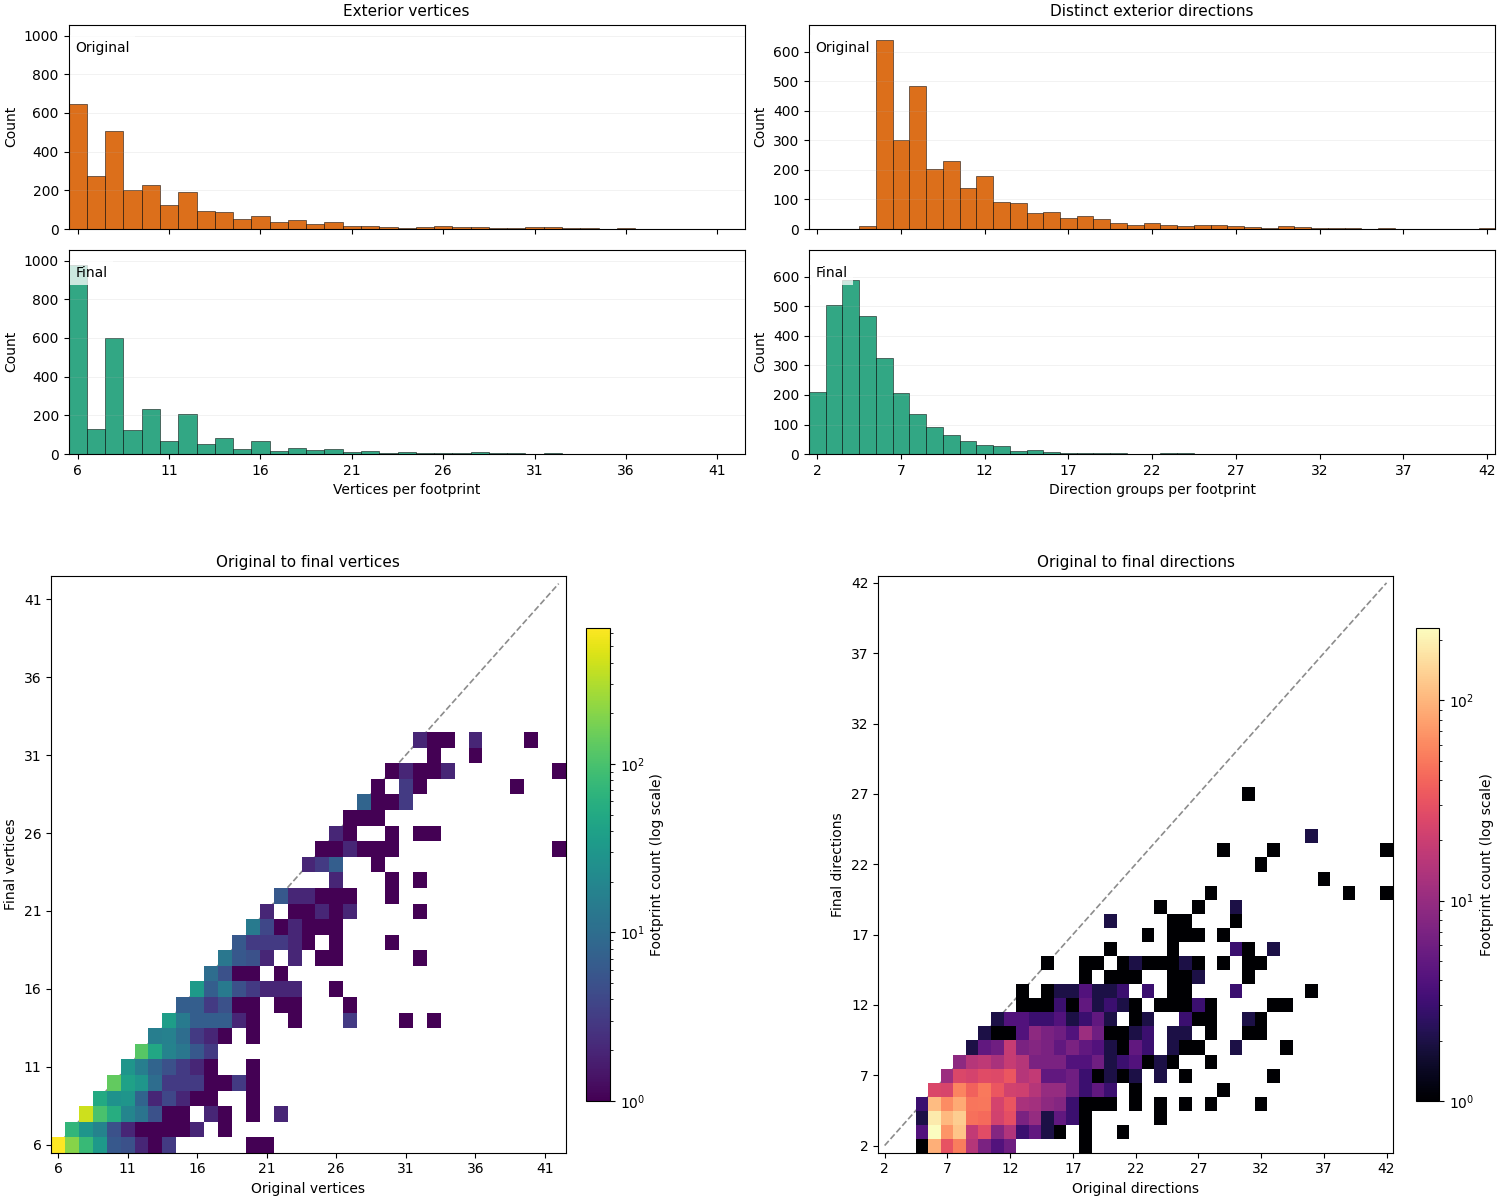

In [19]:
comparison_working_set_df = raw_input_df.loc[raw_input_df['sample_id'].isin(final_subset_df['sample_id'])].copy()
comparison_working_set_df = comparison_working_set_df.merge(
    final_subset_df[['sample_id', 'n_vertices', 'n_unique_directions_final']],
    on='sample_id',
    how='inner',
)
comparison_working_set_df['n_unique_directions_original'] = comparison_working_set_df['geometry'].apply(
    lambda geom: count_exterior_direction_groups(geom, angle_tol_deg=0.0)
)

plot_working_set_prepost_comparison(
    plt=plt,
    original_vertex_values=comparison_working_set_df['n_vertices_original'],
    final_vertex_values=comparison_working_set_df['n_vertices'],
    original_direction_values=comparison_working_set_df['n_unique_directions_original'],
    final_direction_values=comparison_working_set_df['n_unique_directions_final'],
)


### Save the preprocessed working table
Persist `subset_buildings_gdf` to `data/osm/subset_buildings_gdf.pkl` for `OSM_2_Decomposition.ipynb`.


In [20]:
subset_buildings_gdf.to_pickle(SUBSET_BUILDINGS_PATH)
print('Saved subset_buildings_gdf to', SUBSET_BUILDINGS_PATH)
print('Saved the full retained OSM working dataset with', len(subset_buildings_gdf), 'buildings.')


Saved subset_buildings_gdf to /Users/agatadalach/PycharmProjects/FloorplanDecompositionPaper/ConvexDecomp/data/osm/subset_buildings_gdf.pkl
Saved the full retained OSM working dataset with 2755 buildings.
